In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv(r"C:\Users\hp\Downloads\House Price Prediction Dataset.csv")
print("Shape:", df.shape)
display(df.head())

Shape: (2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nStatistical summary:")
display(df.describe(include="all").T)

Shape: (2000, 10)

Columns:
['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']

Data types:
Id           int64
Area         int64
Bedrooms     int64
Bathrooms    int64
Floors       int64
YearBuilt    int64
Location       str
Condition      str
Garage         str
Price        int64
dtype: object

Missing values:


Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


Duplicate rows: 0

Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Area,2000.0,NaN,NaN,NaN,2786.2095,1295.146799,501.0,1653.0,2833.0,3887.5,4999.0
Bedrooms,2000.0,NaN,NaN,NaN,3.0035,1.424606,1.0,2.0,3.0,4.0,5.0
Bathrooms,2000.0,NaN,NaN,NaN,2.5525,1.10899,1.0,2.0,3.0,4.0,4.0
Floors,2000.0,NaN,NaN,NaN,1.9935,0.809188,1.0,1.0,2.0,3.0,3.0
YearBuilt,2000.0,NaN,NaN,NaN,1961.446,35.926695,1900.0,1930.0,1961.0,1993.0,2023.0
Location,2000,4,Downtown,558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Condition,2000,4,Fair,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Garage,2000,2,No,1038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,2000.0,NaN,NaN,NaN,537676.855,276428.845719,50005.0,300098.0,539254.0,780086.0,999656.0


In [5]:
df = df.drop(columns=['Id'])

In [6]:
df = df.drop(columns=['Bathrooms'])

In [7]:
current_year = 2026
df['BuildingAge'] = current_year - df['YearBuilt']
df

,Area,Bedrooms,Floors,YearBuilt,Location,Condition,Garage,Price,BuildingAge
0,1360,5,3,1970,Downtown,Excellent,No,149919,56
1,4272,5,3,1958,Downtown,Excellent,No,424998,68
2,3592,2,3,1938,Downtown,Good,No,266746,88
3,966,4,2,1902,Suburban,Fair,Yes,244020,124
4,4926,1,2,1975,Downtown,Fair,Yes,636056,51
...,...,...,...,...,...,...,...,...,...
1995,4994,5,3,1923,Suburban,Poor,No,295620,103
1996,3046,5,1,2019,Suburban,Poor,Yes,580929,7
1997,1062,5,2,1903,Rural,Poor,No,476925,123
1998,4062,3,2,1936,Urban,Excellent,Yes,161119,90


## X and Y DataFrames


In [8]:

X = df.drop(columns=["Price"])
Y = df["Price"]
print("X shape:", X.shape)
print("Y shape:", Y.shape)

display(X.head())
display(Y.head())

X shape: (2000, 8)
Y shape: (2000,)


,Area,Bedrooms,Floors,YearBuilt,Location,Condition,Garage,BuildingAge
0,1360,5,3,1970,Downtown,Excellent,No,56
1,4272,5,3,1958,Downtown,Excellent,No,68
2,3592,2,3,1938,Downtown,Good,No,88
3,966,4,2,1902,Suburban,Fair,Yes,124
4,4926,1,2,1975,Downtown,Fair,Yes,51


0    149919
1    424998
2    266746
3    244020
4    636056
Name: Price, dtype: int64

## (EDA)

In [9]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['Area', 'Bedrooms', 'Floors', 'YearBuilt', 'BuildingAge']
Categorical: ['Location', 'Condition', 'Garage']


In [10]:

display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))

display(df.nunique().sort_values(ascending=False).to_frame("Unique Values"))

,Missing Values
Area,0
Bedrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0
BuildingAge,0


,Unique Values
Price,1999
Area,1622
YearBuilt,124
BuildingAge,124
Bedrooms,5
Condition,4
Location,4
Floors,3
Garage,2


In [11]:
df[['YearBuilt', 'BuildingAge']].head()

,YearBuilt,BuildingAge
0,1970,56
1,1958,68
2,1938,88
3,1902,124
4,1975,51


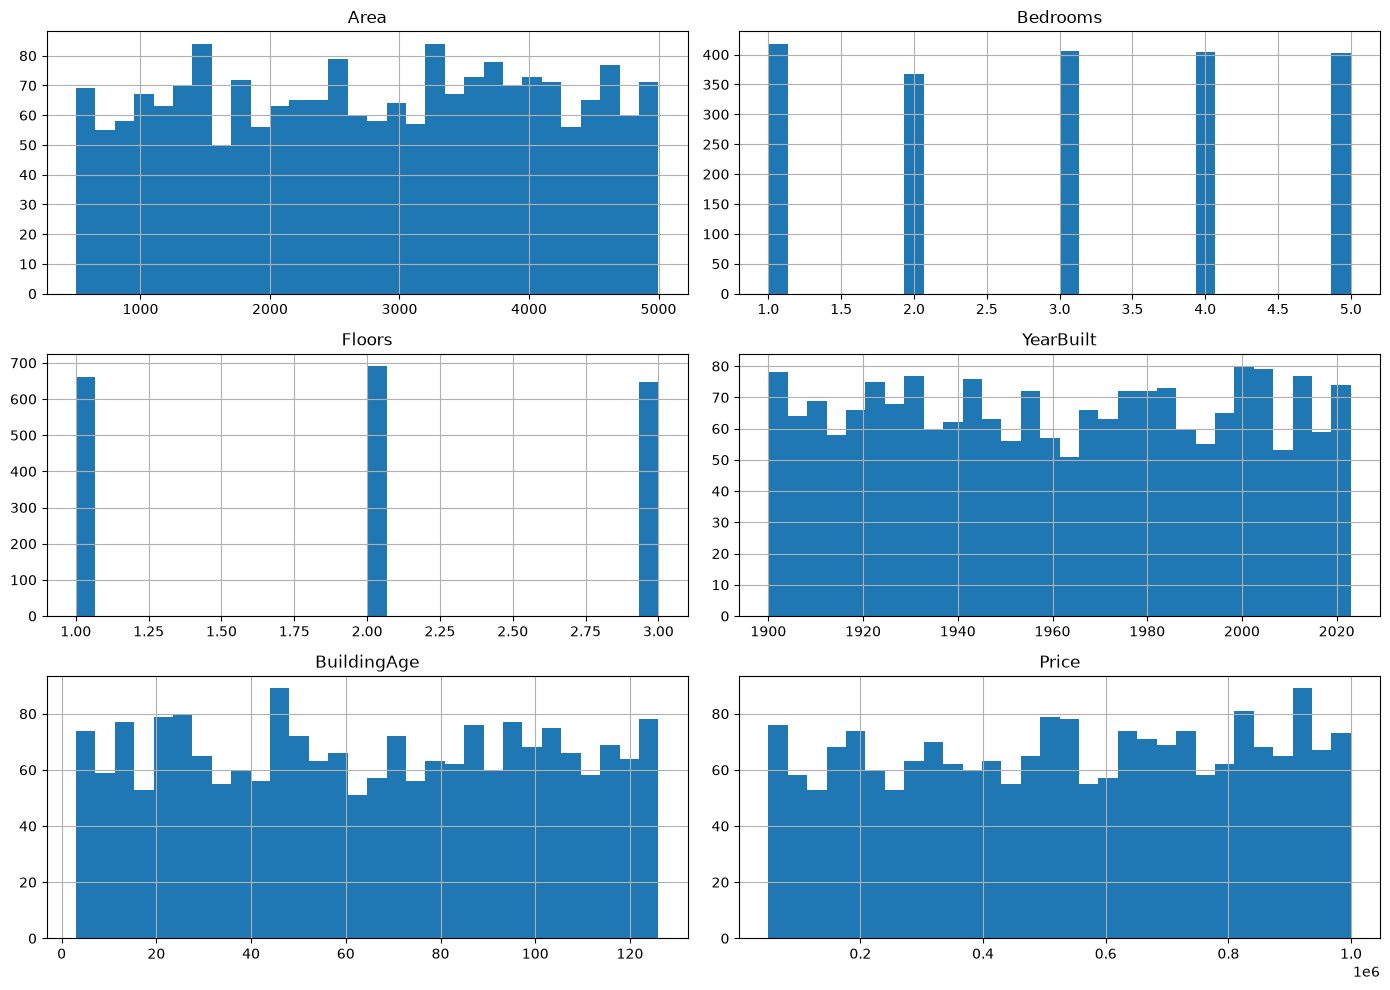

In [12]:

df[numeric_cols + [Y.name]].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

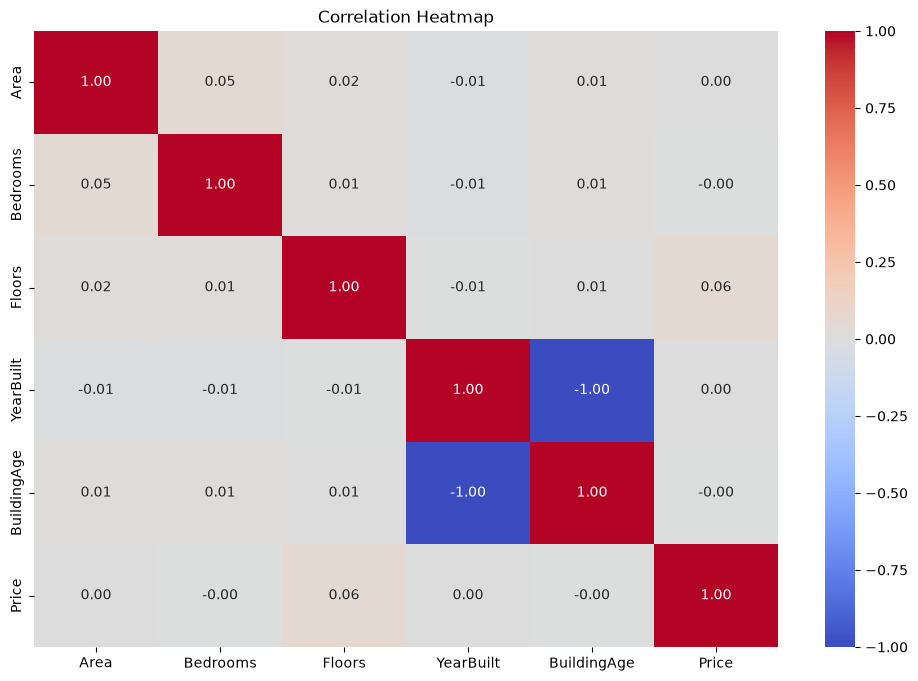

In [13]:

plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols + [Y.name]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

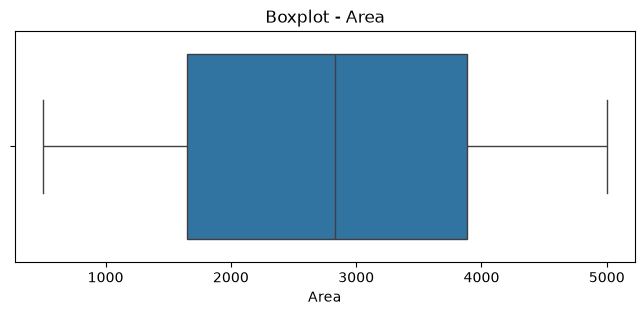

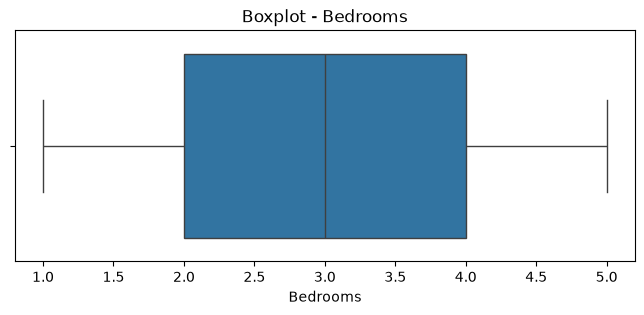

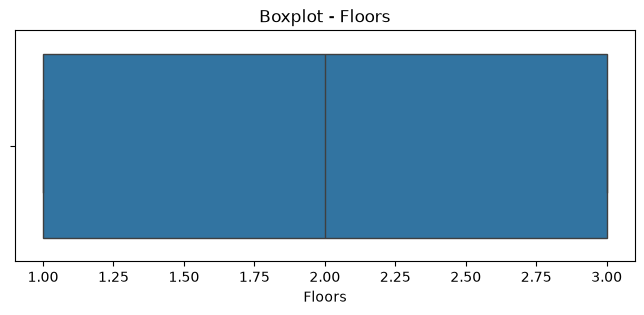

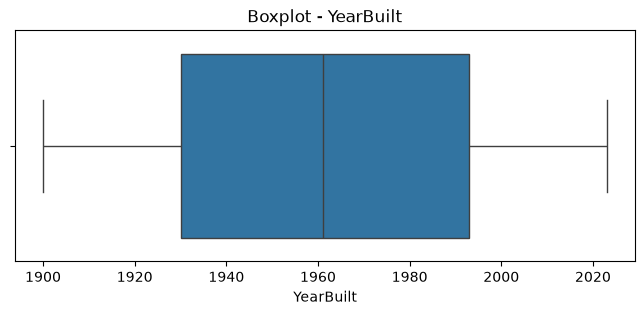

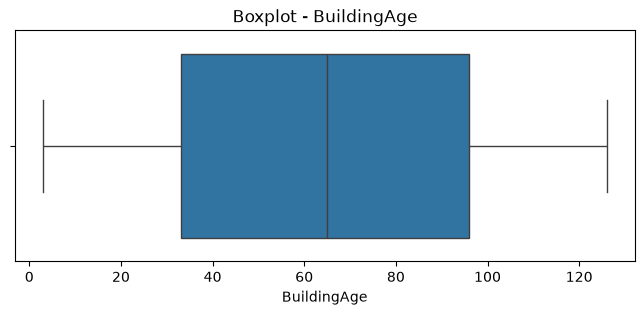

In [14]:

for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

## Train/Test Split



In [15]:
train_x, test_x, train_y, test_y = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print("train_x:", train_x.shape)
print("test_x :", test_x.shape)
print("train_y:", train_y.shape)
print("test_y :", test_y.shape)

train_x: (1600, 8)
test_x : (400, 8)
train_y: (1600,)
test_y : (400,)


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [17]:
train_x_processed = preprocessor.fit_transform(train_x)
test_x_processed = preprocessor.transform(test_x)

feature_names = preprocessor.get_feature_names_out()

train_x_processed = pd.DataFrame(
    train_x_processed,
    columns=feature_names,
    index=train_x.index
)

test_x_processed = pd.DataFrame(
    test_x_processed,
    columns=feature_names,
    index=test_x.index
)

### linear regression

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr_model = LinearRegression()

lr_model.fit(train_x_processed, train_y)

y_pred = lr_model.predict(test_x_processed)

mse = mean_squared_error(test_y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, y_pred)
r2 = r2_score(test_y, y_pred)

print("Model Performance:")
print(f"Mean Squared Error   : {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error  : {mae:.2f}")
print(f"R² Score             : {r2:.4f}")

Model Performance:
Mean Squared Error   : 77759486415.45
Root Mean Squared Error: 278853.88
Mean Absolute Error  : 241960.19
R² Score             : 0.0005


In [19]:
print(df.corr(numeric_only=True)["Price"].sort_values(ascending=False))

Price          1.000000
Floors         0.055890
YearBuilt      0.004845
Area           0.001542
Bedrooms      -0.003471
BuildingAge   -0.004845
Name: Price, dtype: float64


In [20]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


lr_model = LinearRegression()
lr_model.fit(train_x_processed, train_y)

y_pred = lr_model.predict(test_x_processed)



mse = mean_squared_error(test_y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, y_pred)
r2 = r2_score(test_y, y_pred)



feature_names = preprocessor.get_feature_names_out()

print("Model Coefficients:")
for feature, coef in zip(feature_names, lr_model.coef_):
    print(f"{feature}: {coef:.2f}")

print(f"\nIntercept: {lr_model.intercept_:.2f}")

print("\nModel Performance:")
print(f"Mean Squared Error  : {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error : {mae:.2f}")
print(f"R² Score            : {r2:.4f}")

Model Coefficients:
num__Area: -861.09
num__Bedrooms: 147.02
num__Floors: 19016.82
num__YearBuilt: 2167.91
num__BuildingAge: -2167.91
cat__Location_Downtown: -628.56
cat__Location_Rural: 1599.42
cat__Location_Suburban: 11695.77
cat__Location_Urban: -12666.63
cat__Condition_Excellent: -3402.97
cat__Condition_Fair: 20692.17
cat__Condition_Good: -17059.84
cat__Condition_Poor: -229.37
cat__Garage_No: -1013.09
cat__Garage_Yes: 1013.09

Intercept: 535790.21

Model Performance:
Mean Squared Error  : 77759486415.45
Root Mean Squared Error: 278853.88
Mean Absolute Error : 241960.19
R² Score            : 0.0005


### Decision tree regression

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

dt_model = DecisionTreeRegressor(
    random_state=42
)


dt_model.fit(train_x_processed, train_y)

dt_pred = dt_model.predict(test_x_processed)

mse = mean_squared_error(test_y, dt_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, dt_pred)
r2 = r2_score(test_y, dt_pred)

print("Decision Tree Regression Performance:")
print(f"Mean Squared Error      : {mse:.2f}")
print(f"Root Mean Squared Error : {rmse:.2f}")
print(f"Mean Absolute Error     : {mae:.2f}")
print(f"R² Score                : {r2:.4f}")

Decision Tree Regression Performance:
Mean Squared Error      : 160655019833.51
Root Mean Squared Error : 400817.94
Mean Absolute Error     : 325017.68
R² Score                : -1.0650


### bagging 

In [23]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(train_x_processed, train_y)

# Prediction
bagging_pred = bagging_model.predict(train_x_processed)

# Evaluation
bagging_mae = mean_absolute_error(train_y, bagging_pred)
bagging_mse = mean_squared_error(train_y, bagging_pred)
bagging_rmse = np.sqrt(bagging_mse)
bagging_r2 = r2_score(train_y, bagging_pred)

print("Bagging Regression")
print("MAE :", bagging_mae)
print("MSE :", bagging_mse)
print("RMSE:", bagging_rmse)
print("R2  :", bagging_r2)

Bagging Regression
MAE : 91672.040625
MSE : 11766747157.290049
RMSE: 108474.63831370929
R2  : 0.8451896989583505


### booting

In [24]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

ada_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=3,
        random_state=42
    ),
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

ada_model.fit(train_x_processed, train_y)

# Prediction
ada_pred = ada_model.predict(train_x_processed)

# Evaluation
ada_mae = mean_absolute_error(train_y, ada_pred)
ada_mse = mean_squared_error(train_y, ada_pred)
ada_rmse = np.sqrt(ada_mse)
ada_r2 = r2_score(train_y, ada_pred)

print("AdaBoost Regression")
print("MAE :", ada_mae)
print("MSE :", ada_mse)
print("RMSE:", ada_rmse)
print("R2  :", ada_r2)

AdaBoost Regression
MAE : 235829.17779983243
MSE : 74476603051.584
RMSE: 272904.01802022627
R2  : 0.020141659810210877


### Gboosting

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_model.fit(train_x_processed, train_y)

# Prediction
gradient_pred = gradient_model.predict(train_x_processed)

# Evaluation
gradient_mae = mean_absolute_error(train_y, gradient_pred)
gradient_mse = mean_squared_error(train_y, gradient_pred)
gradient_rmse = np.sqrt(gradient_mse)
gradient_r2 = r2_score(train_y, gradient_pred)

print("Gradient Boosting Regression")
print("MAE :", gradient_mae)
print("MSE :", gradient_mse)
print("RMSE:", gradient_rmse)
print("R2  :", gradient_r2)

Gradient Boosting Regression
MAE : 223369.46163028444
MSE : 67587578849.96642
RMSE: 259976.11207564134
R2  : 0.11077774608617752


### SVM Classification

In [26]:
df["Price_Category"] = pd.qcut(
    df["Price"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print(df["Price_Category"].value_counts())

Price_Category
Low       667
High      667
Medium    666
Name: count, dtype: int64


In [27]:
X_class = df.drop(
    columns=["Price", "Price_Category"]
)

Y_class = df["Price_Category"]

print("X shape:", X_class.shape)
print("Y shape:", Y_class.shape)

print("\nTarget distribution:")
print(Y_class.value_counts())

X shape: (2000, 8)
Y shape: (2000,)

Target distribution:
Price_Category
Low       667
High      667
Medium    666
Name: count, dtype: int64


In [28]:
X_train_class, X_test_class, Y_train_class, Y_test_class = train_test_split(
    X_class,
    Y_class,
    test_size=0.20,
    random_state=42,
    stratify=Y_class
)

In [29]:
numeric_cols_class = X_class.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols_class = X_class.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical:", numeric_cols_class)
print("Categorical:", categorical_cols_class)

Numerical: ['Area', 'Bedrooms', 'Floors', 'YearBuilt', 'BuildingAge']
Categorical: ['Location', 'Condition', 'Garage']


In [30]:
numeric_transformer_class = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_class = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor_class = ColumnTransformer([
    ("num", numeric_transformer_class, numeric_cols_class),
    ("cat", categorical_transformer_class, categorical_cols_class)
])

In [31]:
X_train_class_processed = preprocessor_class.fit_transform(
    X_train_class
)

X_test_class_processed = preprocessor_class.transform(
    X_test_class
)

In [32]:
from sklearn.svm import SVC

svc_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

svc_model.fit(
    X_train_class_processed,
    Y_train_class
)

Y_pred_svc = svc_model.predict(
    X_test_class_processed
)

In [33]:
accuracy = accuracy_score(
    Y_test_class,
    Y_pred_svc
)

precision = precision_score(
    Y_test_class,
    Y_pred_svc,
    average="weighted"
)

recall = recall_score(
    Y_test_class,
    Y_pred_svc,
    average="weighted"
)

f1 = f1_score(
    Y_test_class,
    Y_pred_svc,
    average="weighted"
)

print("SVC Classification")
print("------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(
    Y_test_class,
    Y_pred_svc
))

SVC Classification
------------------
Accuracy : 0.3225
Precision: 0.3206525305363146
Recall   : 0.3225
F1 Score : 0.32085936485974015

Classification Report:
              precision    recall  f1-score   support

        High       0.29      0.26      0.28       134
         Low       0.33      0.32      0.32       133
      Medium       0.34      0.38      0.36       133

    accuracy                           0.32       400
   macro avg       0.32      0.32      0.32       400
weighted avg       0.32      0.32      0.32       400



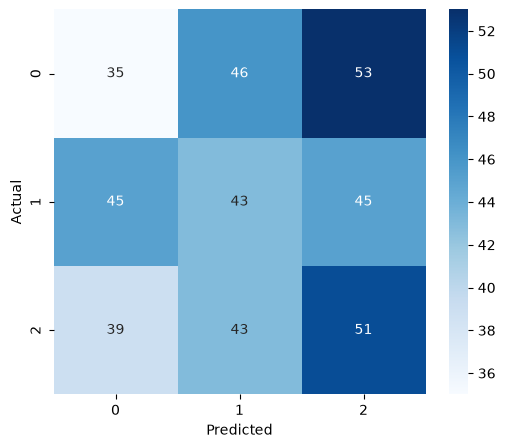

In [34]:
cm = confusion_matrix(
    Y_test_class,
    Y_pred_svc
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### SVM regression

In [35]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel="rbf",
    C=100,
    gamma="scale",
    epsilon=0.1
)

svr_model.fit(
    train_x_processed,
    train_y
)

y_pred_svr = svr_model.predict(
    test_x_processed
)

In [36]:
mse_svr = mean_squared_error(
    test_y,
    y_pred_svr
)

rmse_svr = np.sqrt(mse_svr)

mae_svr = mean_absolute_error(
    test_y,
    y_pred_svr
)

r2_svr = r2_score(
    test_y,
    y_pred_svr
)

print("SVR Regression")
print("--------------")
print("MSE :", mse_svr)
print("RMSE:", rmse_svr)
print("MAE :", mae_svr)
print("R²  :", r2_svr)

SVR Regression
--------------
MSE : 77900600335.6958
RMSE: 279106.7901999086
MAE : 242680.18292138117
R²  : -0.0013081407231008146


### Random forest 

In [37]:
numeric_transformer_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor_rf = ColumnTransformer([
    ("num", numeric_transformer_rf, numeric_cols),
    ("cat", categorical_transformer_rf, categorical_cols)
])

In [38]:
train_x_rf = preprocessor_rf.fit_transform(train_x)

test_x_rf = preprocessor_rf.transform(test_x)

print("RF Train shape:", train_x_rf.shape)
print("RF Test shape :", test_x_rf.shape)

RF Train shape: (1600, 15)
RF Test shape : (400, 15)


In [39]:
rf_regressor = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(
    train_x_rf,
    train_y
)

y_pred_rf = rf_regressor.predict(test_x_rf)

In [40]:
mse_rf = mean_squared_error(test_y, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(test_y, y_pred_rf)
r2_rf = r2_score(test_y, y_pred_rf)

print("Random Forest Regression")
print("------------------------")
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("MAE :", mae_rf)
print("R²  :", r2_rf)

Random Forest Regression
------------------------
MSE : 84185633833.42667
RMSE: 290147.6069751854
MAE : 249775.55765499998
R²  : -0.08209384941951514


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf_regressor = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(train_x_rf, train_y)

rf_y_pred = rf_regressor.predict(test_x_rf)

rf_mse = mean_squared_error(test_y, rf_y_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(test_y, rf_y_pred)
rf_r2 = r2_score(test_y, rf_y_pred)

print("Random Forest Regression")
print("------------------------")
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("MAE :", rf_mae)
print("R²  :", rf_r2)

Random Forest Regression
------------------------
MSE : 82548486810.81094
RMSE: 287312.52463269146
MAE : 247929.03975100673
R²  : -0.06105051170142861


In [42]:
df = pd.read_csv(r"C:\Users\hp\Downloads\House Price Prediction Dataset.csv")

df = df.drop(columns=["Id"])

current_year = 2026
df["BuildingAge"] = current_year - df["YearBuilt"]

X = df.drop(columns=["Price"])
Y = df["Price"]

In [43]:
train_x, test_x, train_y, test_y = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

In [44]:
numeric_cols = train_x.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_x.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'BuildingAge']
Categorical: ['Location', 'Condition', 'Garage']


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_rf = ColumnTransformer([
    ("num", numeric_pipeline_rf, numeric_cols),
    ("cat", categorical_pipeline_rf, categorical_cols)
])

train_x_rf = preprocessor_rf.fit_transform(train_x)
test_x_rf = preprocessor_rf.transform(test_x)

In [46]:
baseline_pred = np.full(len(test_y), train_y.mean())

baseline_r2 = r2_score(test_y, baseline_pred)

print("Baseline R²:", baseline_r2)
print("Random Forest R²:", rf_r2)

Baseline R²: -0.0007164349053967456
Random Forest R²: -0.06105051170142861


In [47]:

corr = df.select_dtypes(include=np.number).corr()

print(corr["Price"].sort_values(ascending=False))

Price          1.000000
Floors         0.055890
YearBuilt      0.004845
Area           0.001542
Bedrooms      -0.003471
BuildingAge   -0.004845
Bathrooms     -0.015737
Name: Price, dtype: float64
